# Model #

I try to put down a model. I will use the xor-perceptron model as a base and modify that.

first create the lattice, N by N, with Nsol = N**2

I should create a class for the cell object and then the network class is formed by cell objects and when the network is created, each network is associated with a position in the lattice.

Note: for now I'm only considering one possible link between each pair neuron for each direction

In [1]:
import numpy as np
from numpy import random as nrd
import matplotlib.pyplot as plt
import graph_tool as gt
from graph_tool.all import *
import copy

import model as m       # I've put all the functions in a separate Python file


(ipykernel_launcher.py:63295): dbind-WARNING **: 12:31:35.184: AT-SPI: Error retrieving accessibility bus address: org.freedesktop.DBus.Error.ServiceUnknown: The name org.a11y.Bus was not provided by any .service files


In [2]:
# parameters of the simulation
par={'N': 10,                    # side length of the squared lattice
     'int_range': 1,             # interaction range
     'p_self_link': 0,         # probability for each cell of having a self link
     'J_range': [-1,+1],                       # define the possible value for J.
     'J_mutation_radius': 0.1,                 # standard deviation of the normal distribution used to sample the mutation value for J.
     'B_mutation_radius': 0.5,            # standard deviation of the normal distribution used to sample the mutation value for B.
     'T_mutation_radius': 2,           # standard deviation of the normal distribution used to sample the mutation value for T.
     'reproduction_ratio': 0.8,          # percentage of offsprings to be generated by reproduction (the reamining by random generation)
     'x_n': np.linspace(-1,1,64),   # discretization of the input of the transfer function (last argmument 
                                   # is also the maximum number of non-zero coefficients in the DFT of the 
                                   # transfer function. it should be a power of 2 for best performance of fft)
     'T_initial': lambda x: 0+1*x,              # initial transfer function shape (here linear)
     'target_set': [0.0,1.0,1.0,0.0],
     'input_set':[[0,0],[0,1],[1,0],[1,1]],
     'n_iter': 100,
     'N_sol': 20}                       # number of solutions (individuals, networks) considered in the simulation

nrd.seed(1234)

In [3]:
solutions, fmean, t_dist_mean, volume_mean = m.evolution(par,verb=3,gen_verb=False)

Iteration #0...
Mean fitness: 13997.289884554088
Parents indexes: [[ 0  3]
 [ 2  1]
 [ 0  3]
 [ 0  2]
 [ 0  3]
 [ 0  3]
 [17  0]
 [ 0 11]]
Selection Probabilities: [0.70921112 0.0739685  0.07264783 0.05799192 0.01767945 0.01229972
 0.01141355 0.00742845 0.00500559 0.00477882 0.0040346  0.00351557
 0.00330177 0.00283655 0.00279364 0.00275256 0.00260164 0.00230218
 0.00185688 0.00157968]
Inverse fitnesses: [2.30990944e-05 2.40916310e-06 2.36614873e-06 1.88880391e-06
 5.75821789e-07 4.00603260e-07 3.71740816e-07 2.41945523e-07
 1.63032619e-07 1.55646754e-07 1.31407555e-07 1.14502409e-07
 1.07538940e-07 9.23868283e-08 9.09891902e-08 8.96512720e-08
 8.47356675e-08 7.49822723e-08 6.04788766e-08 5.14503144e-08]
Iteration #1...
Mean fitness: 683.9279464635923
Parents indexes: [[0 2]
 [1 0]
 [0 4]
 [0 2]
 [0 1]
 [0 1]
 [0 3]
 [0 1]]
Selection Probabilities: [4.77735481e-01 2.07314427e-01 1.72288802e-01 4.94905493e-02
 3.21235620e-02 2.86646664e-02 2.24628399e-02 8.45341062e-03
 1.30489984e-03 1

In [4]:
print(f'# parents: {int(np.floor(par['N_sol'] * par['reproduction_ratio'])-np.floor(par['N_sol'] * par['reproduction_ratio'])%2)}')

# parents: 16


In [5]:
s = copy.deepcopy(solutions)
for sol in s[:20]:
    fitness = m.compute_fitness(sol,par,verb=True)
    print(f'Fitness:{fitness}')

Input: [0, 0] -> Output: 0.8498544636133107
Target distance:0.5216488316745583
Volume cost:1.7485144457345807e-06
Input: [0, 1] -> Output: 0.6690054420598317
Target distance:0.01200282332199555
Volume cost:1.7485144457345807e-06
Input: [1, 0] -> Output: 0.9419472065674683
Target distance:1.1357754818742757e-05
Volume cost:1.7485144457345807e-06
Input: [1, 1] -> Output: -0.5459585520282388
Target distance:0.08884616636175459
Volume cost:1.7485144457345807e-06
Fitness:(0.2846350325664785, 1.133250874067567, 0.005289256198347107)
Input: [0, 0] -> Output: 0.4766981876693229
Target distance:0.05163854576492813
Volume cost:1.7485144457345807e-06
Input: [0, 1] -> Output: 0.46934417869347467
Target distance:0.07929608232599243
Volume cost:1.7485144457345807e-06
Input: [1, 0] -> Output: 0.4762901089101236
Target distance:0.0752251574251192
Volume cost:1.7485144457345807e-06
Input: [1, 1] -> Output: 0.44793584581582685
Target distance:0.04025902677734956
Volume cost:1.7485144457345807e-06
Fitnes

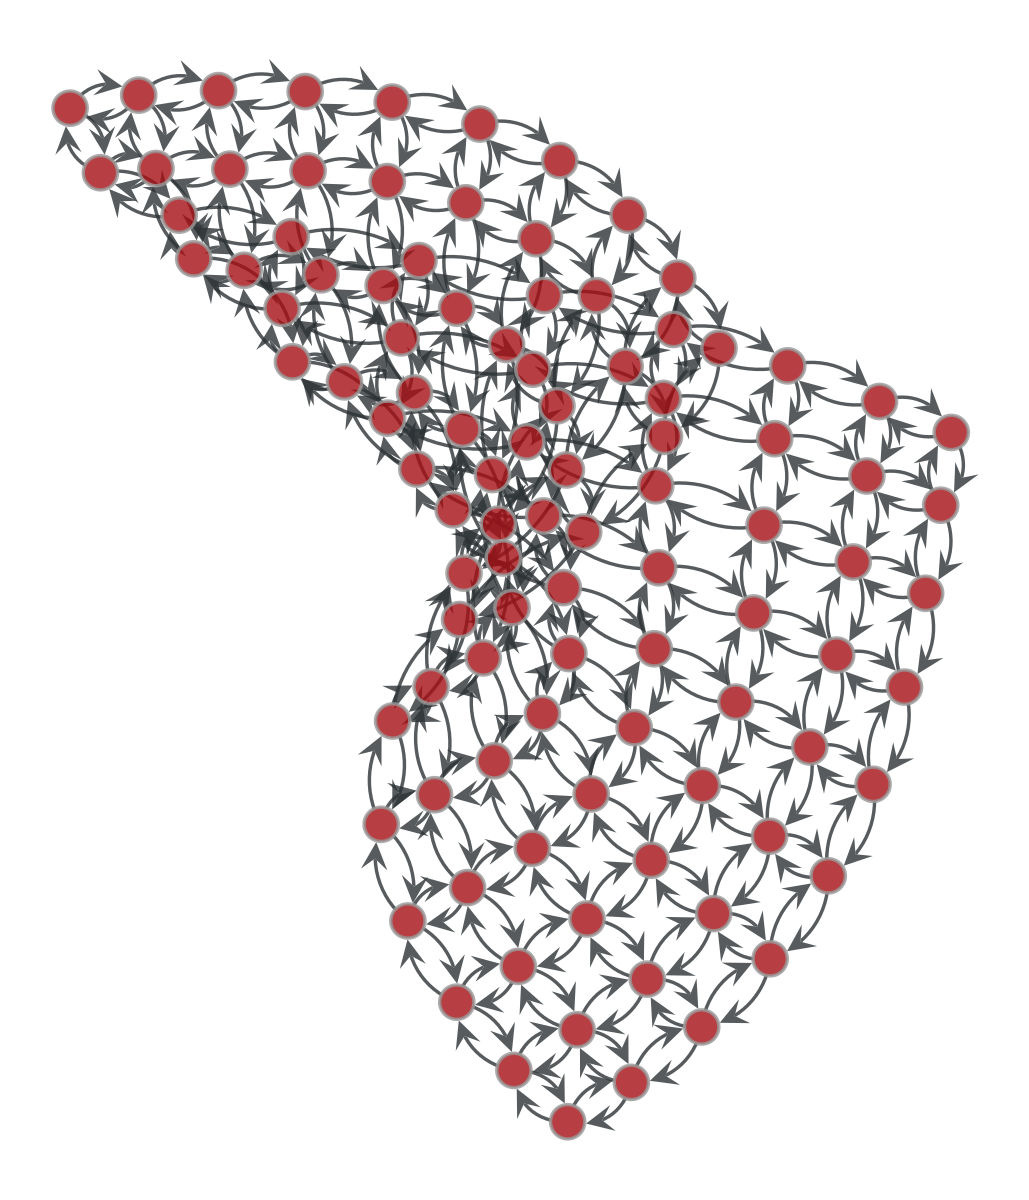

<VertexPropertyMap object with value type 'vector<double>', for Graph 0x7cabf021e540, at 0x7cabf2b3aae0>

In [6]:
graph_draw(s[0].G)

In [7]:
print(f'Percentage of links over the maximum possible:{np.sum(s[0].C)/s[0].C.shape[0]**2}')

Percentage of links over the maximum possible:0.036


In [8]:
def plot_T(T:np.ndarray,par:dict) -> None:
    """Function to plot the shape of the transfer function given the Fourier coefficients.

    Args:
        T (np.ndarray): array of the Fourier coefficients of A SINGLE cell.
        par (dict): simulation parameters.
    """
    f_n = np.fft.irfft(T)
    coeff = np.polyfit(par['x_n'],f_n,3)    # fit the series of function value with a polynomial of degree up to 5
    new_fun = np.poly1d(coeff)                      # generate the new functional from the fit results
    x = np.linspace(min(par['x_n']),max(par['x_n']),1000)
    x = np.linspace(-10,10,1000)
    plt.plot(x,new_fun(x))
    plt.grid()
    plt.xlabel('x')
    plt.ylabel('f(x)')
    plt.title('Transfer function')
    plt.show()

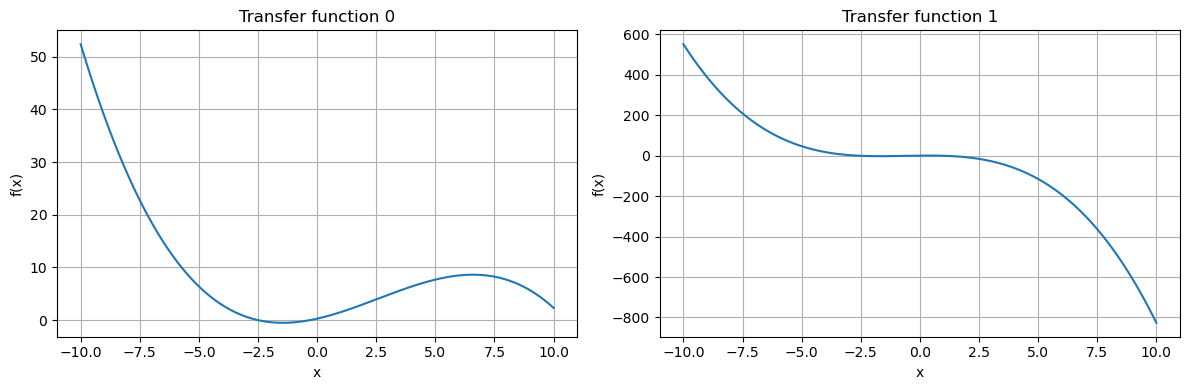

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for i in range(2):
    f_n = np.fft.irfft(solutions[0].T[i])
    coeff = np.polyfit(par['x_n'], f_n, 3)
    new_fun = np.poly1d(coeff)
    x = np.linspace(min(par['x_n']), max(par['x_n']), 1000)
    x = np.linspace(-10, 10, 1000)
    axes[i].plot(x, new_fun(x))
    axes[i].grid()
    axes[i].set_xlabel('x')
    axes[i].set_ylabel('f(x)')
    axes[i].set_title(f'Transfer function {i}')
plt.tight_layout()
plt.show()

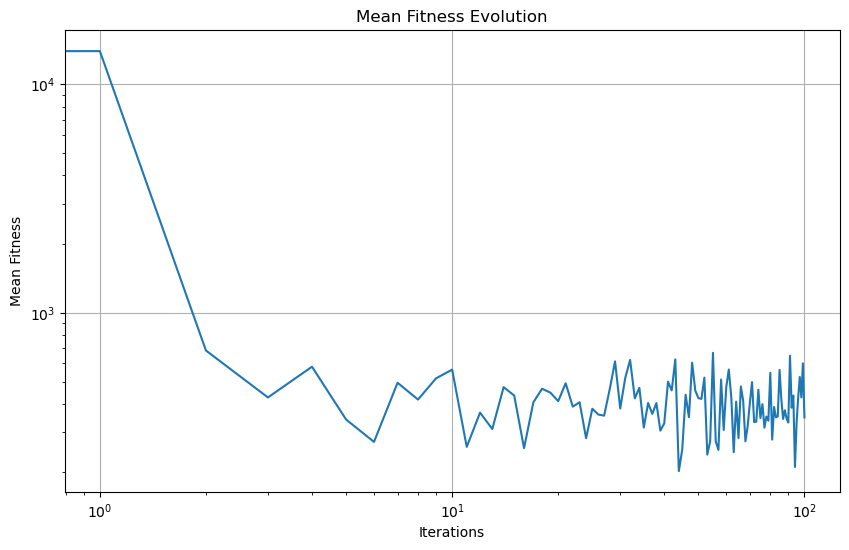

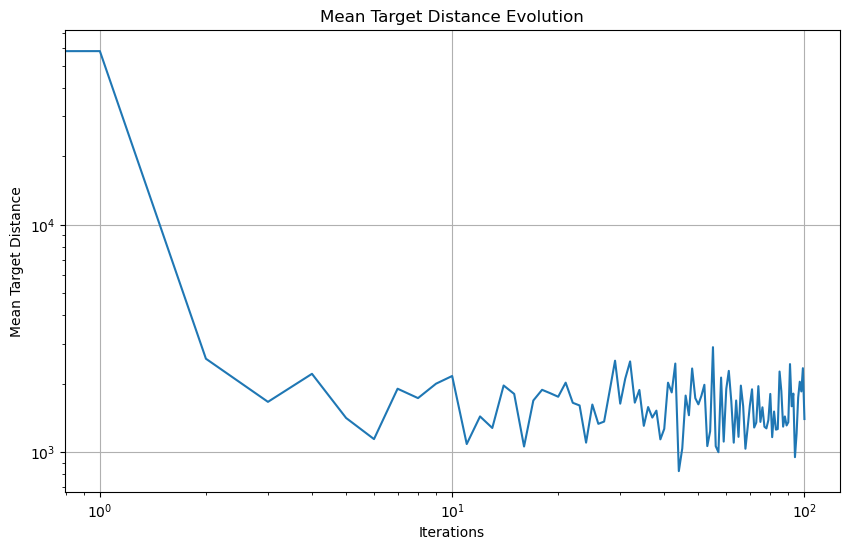

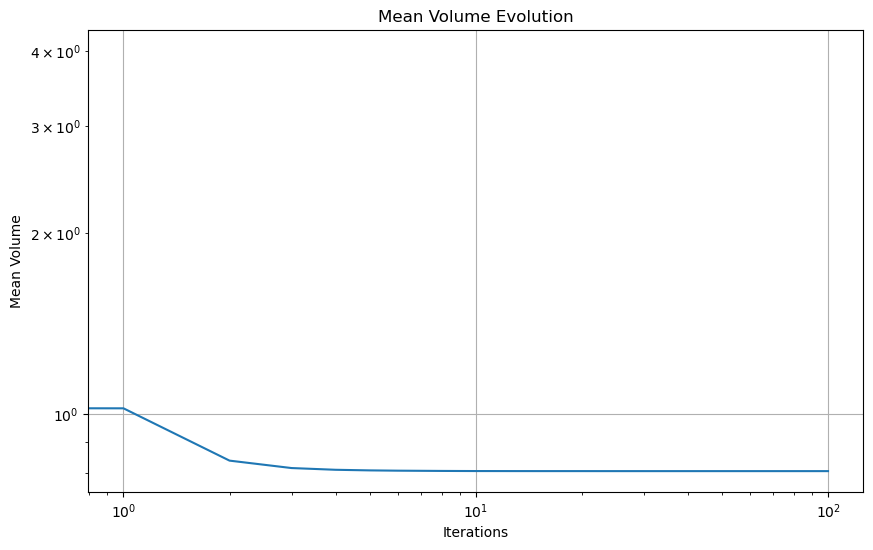

In [10]:
plt.figure(figsize=(10, 6))
plt.plot(fmean)
plt.title('Mean Fitness Evolution')
plt.xlabel('Iterations')
plt.ylabel('Mean Fitness')
plt.yscale('log')
plt.xscale('log')
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(t_dist_mean)
plt.title('Mean Target Distance Evolution')
plt.xlabel('Iterations')
plt.ylabel('Mean Target Distance')
plt.yscale('log')
plt.xscale('log')
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(volume_mean)
plt.title('Mean Volume Evolution')
plt.xlabel('Iterations')
plt.ylabel('Mean Volume')
plt.yscale('log')
plt.xscale('log')
plt.grid(True)
plt.show()